In [1]:
import torch
import torch.nn as nn
import timm
from tqdm import tqdm

In [2]:
!pip install -U albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.4/369.4 kB 10.3 MB/s eta 0:00:0000:01
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.23
    Uninstalling albucore-0.0.23:
      Successfully uninstalled albucore-0.0.23
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.5
    Uninstalling albumentations-2.0.5:
      Successfully uninstalled albumentations-2.0.5


In [3]:
!pip install ultralytics opencv-python


In [20]:
! ls /kaggle/working/

In [4]:
import os
import cv2
import torch
from ultralytics import YOLO
import numpy as np
from tqdm import tqdm

# 🔧 Настройки
SOURCE_DIR = "/kaggle/input/cars-dataset/intro-dl-2025/train/train"        # Папка с исходными изображениями
DEST_DIR = "train"      # Куда сохранять маскированные
os.makedirs(DEST_DIR, exist_ok=True)

# 🚗 Загружаем YOLOv8 с сегментацией
model = YOLO("yolov8x-seg.pt")  # Можно заменить на yolov8m-seg.pt для ускорения



In [ ]:
for filename in tqdm(os.listdir(SOURCE_DIR)):

    image_path = os.path.join(SOURCE_DIR, filename)
    image = cv2.imread(image_path)
   
    results = model(image)
    r = results[0]

    boxes = r.boxes
    masks = r.masks

    if masks is None or boxes is None or boxes.cls is None:
        # Машина не найдена — сохранить оригинал
        cv2.imwrite(os.path.join(DEST_DIR, filename), image)
        continue

    masks_np = masks.data.cpu().numpy()
    confidences = boxes.conf.cpu().numpy()
    class_ids = boxes.cls.cpu().numpy()

    # Ищем индексы машин (class_id == 2)
    car_indices = [i for i, cls in enumerate(class_ids) if int(cls) == 2]

    if not car_indices:
        # Машина не найдена — сохранить оригинал
        cv2.imwrite(os.path.join(DEST_DIR, filename), image)
        continue

    # Выбираем машину с максимальной уверенностью
    best_car_idx = max(car_indices, key=lambda i: confidences[i])
    best_mask = masks_np[best_car_idx]
    best_box = boxes.xyxy[best_car_idx].cpu().numpy().astype(int)

    # Маску ресайзим под оригинальный размер
    mask_resized = cv2.resize((best_mask > 0.5).astype(np.uint8) * 255,
                              (r.orig_shape[1], r.orig_shape[0]),
                              interpolation=cv2.INTER_NEAREST)

    # Применяем маску
    masked_image = cv2.bitwise_and(image, image, mask=mask_resized)

    # Обрезаем по bbox
    x1, y1, x2, y2 = best_box
    masked_cropped = masked_image[y1:y2, x1:x2]

    # Сохраняем
    save_path = os.path.join(DEST_DIR, filename)
    cv2.imwrite(save_path, masked_cropped)


  0%|          | 0/8144 [00:00<?, ?it/s]


0: 448x640 1 person, 1 car, 48.6ms
Speed: 9.8ms preprocess, 48.6ms inference, 209.2ms postprocess per image at shape (1, 3, 448, 640)


  0%|          | 1/8144 [00:01<3:14:16,  1.43s/it]


0: 480x640 9 cars, 45.9ms
Speed: 2.4ms preprocess, 45.9ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

0: 544x640 1 car, 45.9ms
Speed: 4.3ms preprocess, 45.9ms inference, 2.5ms postprocess per image at shape (1, 3, 544, 640)


  0%|          | 3/8144 [00:01<57:48,  2.35it/s]  

...


0: 384x640 1 car, 30.7ms
Speed: 1.3ms preprocess, 30.7ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 320x640 1 car, 28.6ms
Speed: 0.8ms preprocess, 28.6ms inference, 1.8ms postprocess per image at shape (1, 3, 320, 640)

0: 480x640 1 car, 34.3ms
Speed: 1.3ms preprocess, 34.3ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


 59%|█████▊    | 4781/8144 [04:31<02:53, 19.33it/s]


0: 416x640 1 car, 31.5ms
Speed: 1.8ms preprocess, 31.5ms inference, 1.8ms postprocess per image at shape (1, 3, 416, 640)

0: 480x640 1 truck, 34.4ms
Speed: 1.7ms preprocess, 34.4ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


 59%|█████▊    | 4783/8144 [04:31<02:57, 18.93it/s]


0: 480x640 1 car, 33.7ms
Speed: 1.3ms preprocess, 33.7ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 car, 33.7ms
Speed: 1.4ms preprocess, 33.7ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


In [3]:
class LabelSmoothing(nn.Module):
    def __init__(self, smoothing=0.0):
        """
        Инициализирует модуль Label Smoothing.
        
        Параметры:
        ----------
        smoothing : float, default=0.0
            Коэффициент сглаживания, значение от 0.0 до 1.0.
            - 0.0: без сглаживания (эквивалентно стандартному CrossEntropyLoss)
            - 1.0: полное сглаживание (равномерное распределение по всем классам)
            
            Типичные значения: 0.1, 0.2. Значения выше 0.2 обычно не рекомендуются.
        """
        super(LabelSmoothing, self).__init__()
        self.confidence = 1.0 - smoothing  # Вес для правильного класса
        self.smoothing = smoothing         # Вес для распределения по всем классам

    def forward(self, x, target):
        # Вычисляем логарифм вероятностей (log-softmax)
        logprobs = torch.nn.functional.log_softmax(x, dim=-1)
        
        # Вычисляем стандартную NLL loss для правильных классов
        # gather выбирает логарифм вероятности для правильного класса
        nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)  # Убираем лишнюю размерность
        
        # Вычисляем loss для равномерного распределения (среднее по всем классам)
        # Это эквивалентно KL-дивергенции между предсказанием и равномерным распределением
        smooth_loss = -logprobs.mean(dim=-1)
        
        # Комбинируем потери с соответствующими весами
        # confidence * (потеря для правильного класса) + smoothing * (потеря для равномерного распределения)
        loss = self.confidence * nll_loss + self.smoothing * smooth_loss
        
        # Возвращаем среднее значение потери по батчу
        return loss.mean()

In [4]:
import albumentations as A
transform = A.Compose([
    A.Resize(400, 400),
    A.Normalize(),
])

In [5]:
import os
import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset
import cv2

class CarDataset(Dataset):
    """
    Датасет для классификации изображений автомобилей.
    
    Этот класс наследуется от torch.utils.data.Dataset и предназначен для загрузки
    и предобработки изображений автомобилей для задачи классификации.
    
    Атрибуты:
    ---------
    df : pandas.DataFrame
        DataFrame, содержащий информацию о файлах изображений и их метках.
    phase : str
        Фаза работы ('train', 'val', 'test'), определяет поддиректорию с данными.
    dataroot : str
        Корневая директория, содержащая данные.
    transforms : callable, optional
        Функция трансформации изображений (например, из библиотеки albumentations).
    
    Примечания:
    -----------
    Датасет ожидает, что DataFrame содержит как минимум две колонки:
    - 'filename': имя файла изображения
    - 'label': метка класса (целое число)
    """
    
    def __init__(self, df_filename, phase, dataroot='/kaggle/input/cars-dataset/intro-dl-2025', segm_dataroot = '/kaggle/input/segmented-cars', transforms=None):
        """
        Инициализирует экземпляр класса CarDataset.
        
        Параметры:
        ----------
        df_filename : str или pandas.DataFrame
            Путь к CSV-файлу с данными или уже загруженный DataFrame.
            Если передан DataFrame, он используется напрямую.
        phase : str
            Фаза работы ('train', 'val', 'test'), определяет поддиректорию с данными.
        dataroot : str, default='/datasets/train_classifier/kaggle_cars/'
            Корневая директория, содержащая данные.
        transforms : callable, optional
            Функция трансформации изображений (например, из библиотеки albumentations).
        """
        # Если df_filename - строка, считаем, что это путь к CSV-файлу
        if isinstance(df_filename, str):
            self.df = pd.read_csv(df_filename)
        else:
            # Иначе считаем, что это уже DataFrame
            self.df = df_filename
            
        self.phase = phase
        self.dataroot = dataroot
        self.segm_dataroot = segm_dataroot
        self.transforms = transforms

    def __getitem__(self, idx):
        """
        Возвращает пару (изображение, метка) по указанному индексу.
        
        Параметры:
        ----------
        idx : int
            Индекс элемента для загрузки.
            
        Возвращает:
        -----------
        tuple
            Кортеж (изображение, метка), где:
            - изображение: torch.Tensor размера [3, H, W]
            - метка: int, метка класса
        """
        filename = self.df.iloc[idx]['filename']
        label = self.df.iloc[idx]['label']

        # Загружаем изображение с помощью OpenCV
        image = cv2.imread(os.path.join(self.dataroot, self.phase, self.phase, filename))

        
        # Применяем трансформации, если они заданы
        if self.transforms is not None:
            if torch.rand(1) > 0.6 and self.phase=='train':
                image= cv2.imread(os.path.join(self.segm_dataroot, self.phase, filename))
            
            image = self.transforms(image=image)['image']
                

        # Изменяем размер изображения и выполняем предобработку
        image = image.transpose(2, 0, 1)


        # Преобразуем изображение в тензор PyTorch
        return torch.from_numpy(image).float(), label

    def __len__(self):
        """ it
        Возвращает количество элементов в датасете.
        
        Возвращает:
        -----------
        int
            Количество элементов в датасете.
        """
        return len(self.df)


train_dataset = CarDataset(df_filename='/kaggle/input/cars-dataset/intro-dl-2025/train.csv',
                               phase='train', transforms=transform)

    # Получаем одно изображение и его метку
image, label = train_dataset.__getitem__(100)
print(f"Размер изображения: {image.size()}, Метка класса: {label}")

Размер изображения: torch.Size([3, 400, 400]), Метка класса: 2


In [8]:
len(train_dataset)

8144

In [28]:
w = []
h = []
for image, label in CarDataset(df_filename='/kaggle/input/cars-dataset/intro-dl-2025/train.csv',
                               phase='train'):
    w.append(image.size(1))
    h.append(image.size(2))

In [29]:
data1.mean(), data2.mean()

(482.7719793713163, 699.7930992141454)

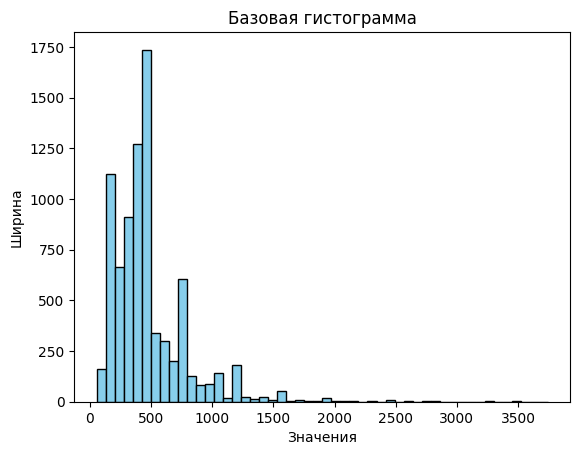

In [28]:
import matplotlib.pyplot as plt
import numpy as np  
  
# Генерируем случайные данные
data1 = np.array(w)
  
  
# Построение гистограммы
plt.hist(data1, bins=50, color='skyblue', edgecolor='black')  
# Добавление меток и заголовка
plt.xlabel('Значения')
plt.ylabel('Ширина')
plt.title('Базовая гистограмма')  
# Отображение графика
plt.show()  

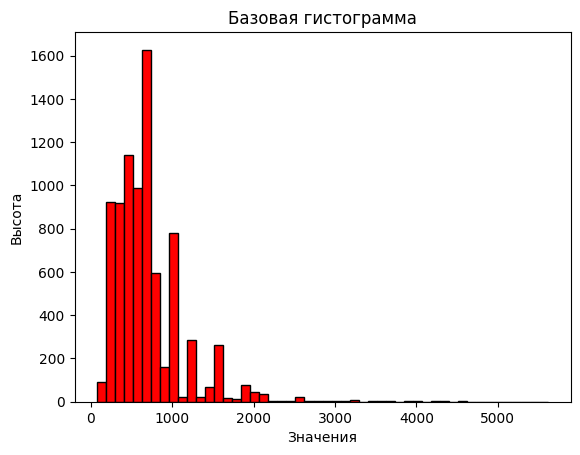

In [26]:
import matplotlib.pyplot as plt
import numpy as np  
  
# Генерируем случайные данные
data2 = np.array(h)
  
  
# Построение гистограммы
plt.hist(data2, bins=50, color='red', edgecolor='black')  
# Добавление меток и заголовка
plt.xlabel('Значения')
plt.ylabel('Высота')
plt.title('Базовая гистограмма')  
# Отображение графика
plt.show()  

In [6]:
def get_model(model_name, num_classes=196, pretrained=True):
    model = timm.create_model(model_name, pretrained, num_classes=num_classes)
    last = list(model.named_children())[-1]
    classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(last[1].in_features, num_classes)
    )

    setattr(model, last[0], classifier)

    return model

resnet_model = get_model('resnet50', num_classes=196)
    
    # Создание модели EfficientNet-B0
efficientnet_model = get_model('efficientnet_b2', num_classes=196)
    
    # Создание модели Vision Transformer без предобученных весов
vit_model = get_model('vit_base_patch16_224', num_classes=196, pretrained=False)
    
    # Вывод структуры модели
dummy_input = torch.randn(1, 3, 224, 224)  # Batch size 1, 3 канала, размер 224x224
print(resnet_model(dummy_input).shape)  #

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

torch.Size([1, 196])


In [8]:
timm.list_models()

['aimv2_1b_patch14_224',
 'aimv2_1b_patch14_336',
 'aimv2_1b_patch14_448',
 'aimv2_3b_patch14_224',
 'aimv2_3b_patch14_336',
 'aimv2_3b_patch14_448',
 'aimv2_huge_patch14_224',
 'aimv2_huge_patch14_336',
 'aimv2_huge_patch14_448',
 'aimv2_large_patch14_224',
 'aimv2_large_patch14_336',
 'aimv2_large_patch14_448',
 'bat_resnext26ts',
 'beit_base_patch16_224',
 'beit_base_patch16_384',
 'beit_large_patch16_224',
 'beit_large_patch16_384',
 'beit_large_patch16_512',
 'beitv2_base_patch16_224',
 'beitv2_large_patch16_224',
 'botnet26t_256',
 'botnet50ts_256',
 'caformer_b36',
 'caformer_m36',
 'caformer_s18',
 'caformer_s36',
 'cait_m36_384',
 'cait_m48_448',
 'cait_s24_224',
 'cait_s24_384',
 'cait_s36_384',
 'cait_xs24_384',
 'cait_xxs24_224',
 'cait_xxs24_384',
 'cait_xxs36_224',
 'cait_xxs36_384',
 'coat_lite_medium',
 'coat_lite_medium_384',
 'coat_lite_mini',
 'coat_lite_small',
 'coat_lite_tiny',
 'coat_mini',
 'coat_small',
 'coat_tiny',
 'coatnet_0_224',
 'coatnet_0_rw_224',
 'coa

In [17]:
! rm -rf /kaggle/working/

rm: cannot remove '/kaggle/working/': Device or resource busy


In [7]:
sum(p.numel() for p in get_model('resnet50', num_classes=196).parameters())

23909636

In [8]:
val_transform = A.Compose([
    A.Resize(400, 400),
    A.Normalize(),
])

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
import albumentations as A


transform = A.Compose([
    A.RandomResizedCrop((284, 284), scale=(0.8, 1.0), ratio=(0.8, 1.2), p=0.3),
    A.HorizontalFlip(p=0.5),
    #A.Rotate(limit=10, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=15, p=0.5),
    A.Perspective(scale=(0.03, 0.07), keep_size=True, p=0.4),
     
    A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.5),
    A.ChannelShuffle(p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=10, val_shift_limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    #A.CLAHE(p=0.2),
    
    A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.3),
    #A.MotionBlur(p=0.2),
    #A.GaussianBlur(blur_limit=(3,5), p=0.2),

    A.Resize(400, 400),
    A.Normalize(),
])

annotation_path = '/kaggle/input/cars-dataset/intro-dl-2025/train.csv'
df = pd.read_csv(annotation_path)

train_df, val_df = train_test_split(df, test_size=0.15, random_state=2025, stratify=df['label'])

train_dataset = CarDataset(train_df, phase='train',  transforms=transform)
val_dataset = CarDataset(val_df, phase='train', transforms=val_transform)


model = get_model('resnet18')
model.load_state_dict(torch.load('/kaggle/input/model91/Model_0.91.pth'))

model.cuda()


criterion = LabelSmoothing(smoothing=0.1) 
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, min_lr=1e-5,
                                                           patience=5, verbose=True)
#lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, 25, eta_min=0.0, last_epoch=-1)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=200, num_workers=4,
                                            shuffle=True, pin_memory=True)

val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=256, num_workers=4,
                                        shuffle=False, pin_memory=True)
best_acc = 0
for epoch in tqdm(range(50)):
    
    train_loss = 0
    train_acc = 0

    model.train()
    for batch_idx, (images, target) in tqdm(enumerate(train_loader)):

        images, target = images.cuda(), target.cuda()

        optimizer.zero_grad()

        # forward
        output = model(images)

        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_acc += (output.argmax(dim=1) == target).sum().item()

    train_loss /= len(train_dataset)
    train_acc /= len(train_dataset)

    print(f'Epoch {epoch}')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc * 100:.2f}%')

    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for batch_idx, (images, target) in enumerate(val_loader):
            images, target = images.cuda(), target.cuda()

            output = model(images)

            loss = criterion(output, target)
            val_loss += loss.item() * images.size(0)
            val_acc += (output.argmax(dim=1) == target).sum().item()

    val_loss /= len(val_dataset)
    val_acc /= len(val_dataset)

    lr_scheduler.step(val_acc)

    print(f'Epoch {epoch}')
    print(f'VAL Loss: {val_loss:.4f}, VAL Acc: {val_acc * 100:.2f}%')  

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), f'Model_{best_acc:.2f}.pth')

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
  0%|          | 0/50 [00:00<?, ?it/s]
0it [00:00, ?it/s]
1it [00:10, 10.87s/it]
2it [00:12,  5.51s/it]
3it [00:14,  3.80s/it]
4it [00:16,  2.99s/it]
5it [00:18,  2.93s/it]
6it [00:20,  2.54s/it]
7it [00:22,  2.29s/it]
8it [00:24,  2.13s/it]
9it [00:28,  2.74s/it]
10it [00:30,  2.44s/it]
11it [00:31,  2.24s/it]
12it [00:33,  2.10s/it]
13it [00:38,  2.85s/it]
14it [00:40,  2.53s/it]
15it [00:41,  2.30s/it]
16it [00:43,  2.15s/it]
17it [00:50,  3.55s/it]
18it [00:52,  3.02s/it]
19it [00:54,  2.65s/it]
20it [00:55,  2.40s/it]
21it [01:01,  3.52s/it]
22it [01:03,  3.00s/it]
23i

Epoch 0
Train Loss: 1.4400, Train Acc: 89.90%



  2%|▏         | 1/50 [01:42<1:23:59, 102.84s/it]

Epoch 0
VAL Loss: 1.5980, VAL Acc: 84.21%



0it [00:00, ?it/s]
1it [00:10, 10.13s/it]
2it [00:13,  5.88s/it]
3it [00:14,  4.01s/it]
4it [00:16,  3.14s/it]
5it [00:19,  2.97s/it]
6it [00:23,  3.23s/it]
7it [00:24,  2.77s/it]
8it [00:26,  2.46s/it]
9it [00:28,  2.26s/it]
10it [00:32,  2.69s/it]
11it [00:33,  2.42s/it]
12it [00:35,  2.23s/it]
13it [00:37,  2.11s/it]
14it [00:40,  2.29s/it]
15it [00:42,  2.15s/it]
16it [00:43,  2.05s/it]
17it [00:45,  1.98s/it]
18it [00:49,  2.61s/it]
19it [00:51,  2.37s/it]
20it [00:53,  2.21s/it]
21it [00:55,  2.27s/it]
22it [00:58,  2.45s/it]
23it [01:00,  2.27s/it]
24it [01:02,  2.14s/it]
25it [01:07,  2.89s/it]
26it [01:08,  2.58s/it]
27it [01:10,  2.35s/it]
28it [01:12,  2.20s/it]
29it [01:14,  2.16s/it]
30it [01:16,  2.07s/it]
31it [01:18,  2.00s/it]
32it [01:20,  1.95s/it]
33it [01:22,  2.03s/it]
34it [01:24,  1.97s/it]
35it [01:25,  2.44s/it]

...


0it [00:00, ?it/s]
1it [00:11, 11.47s/it]
2it [00:13,  5.80s/it]
3it [00:15,  3.99s/it]
4it [00:16,  3.14s/it]
5it [00:19,  2.87s/it]
6it [00:21,  2.52s/it]
7it [00:23,  2.30s/it]
8it [00:24,  2.16s/it]
9it [00:27,  2.35s/it]
10it [00:29,  2.20s/it]
11it [00:31,  2.09s/it]
12it [00:33,  2.02s/it]
13it [00:36,  2.52s/it]
14it [00:38,  2.32s/it]
15it [00:40,  2.18s/it]
16it [00:42,  2.09s/it]
17it [00:46,  2.77s/it]
18it [00:48,  2.49s/it]
19it [00:50,  2.30s/it]
20it [00:52,  2.17s/it]
21it [00:55,  2.52s/it]
22it [00:57,  2.42s/it]
23it [00:59,  2.26s/it]
24it [01:01,  2.14s/it]
25it [01:05,  2.54s/it]
26it [01:07,  2.53s/it]
27it [01:09,  2.33s/it]
28it [01:11,  2.19s/it]
29it [01:14,  2.50s/it]
30it [01:16,  2.31s/it]
31it [01:18,  2.18s/it]
32it [01:20,  2.10s/it]
33it [01:22,  2.15s/it]
34it [01:24,  2.07s/it]
35it [01:25,  2.45s/it]

Epoch 9
Train Loss: 1.3001, Train Acc: 92.79%



 20%|██        | 10/50 [15:59<1:03:31, 95.29s/it]

Epoch 9
VAL Loss: 1.5517, VAL Acc: 84.86%



0it [00:00, ?it/s]
1it [00:10, 10.11s/it]
2it [00:11,  5.24s/it]
3it [00:13,  3.69s/it]
4it [00:15,  2.97s/it]
5it [00:19,  3.16s/it]
6it [00:20,  2.71s/it]
7it [00:22,  2.43s/it]
8it [00:24,  2.25s/it]
9it [00:27,  2.47s/it]
10it [00:29,  2.28s/it]
11it [00:31,  2.15s/it]
12it [00:33,  2.07s/it]
13it [00:38,  3.04s/it]
14it [00:40,  2.69s/it]
15it [00:42,  2.44s/it]
16it [00:44,  2.27s/it]
17it [00:47,  2.57s/it]
18it [00:49,  2.36s/it]
19it [00:51,  2.21s/it]
20it [00:53,  2.11s/it]
21it [00:56,  2.43s/it]
22it [00:58,  2.26s/it]
23it [01:00,  2.45s/it]
24it [01:02,  2.28s/it]
25it [01:04,  2.23s/it]
26it [01:06,  2.12s/it]
27it [01:10,  2.69s/it]
28it [01:12,  2.44s/it]Exception in thread Thread-32 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist

In [1]:
! ls

In [12]:
model = get_model('resnet18')
model.load_state_dict(torch.load('/kaggle/input/model91/Model_0.91.pth'))
model.cuda()
model.eval()


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, m

In [14]:
import os
from glob import glob
from PIL import Image
#test_dir = '/kaggle/input/cars-dataset/intro-dl-2025/test/test'
test_dir = '/kaggle/input/segmented-cars/test'

val_transform = A.Compose([
    A.Resize(400, 400),
    A.Normalize(),
])

class TestData(Dataset):
    def __init__(self, root_dir, transform=val_transform):
        self.image_paths = glob(os.path.join(root_dir, '*.jpg'))  # Только файлы в root_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        filename = os.path.basename(img_path)  # Вернёт 'file.jpg'
        image = cv2.imread(img_path)
       
        if self.transform is not None:
            image = self.transform(image=image)['image']

        #image0 = self.transforms(image=image)['image']
        image = image.transpose(2, 0, 1)
        #image1 = self.transform(image=image)['image']
        #image1 = image.transpose(2, 0, 1)
        #image2 = self.transform(image=image)['image']
        #image2 = image.transpose(2, 0, 1)
      

        # Преобразуем изображение в тензор PyTorch
        return filename, torch.from_numpy(image).float()#, torch.from_numpy(image1).float(),torch.from_numpy(image2).float()
   
  

test_dataset = TestData(test_dir)

In [16]:
results = []

# Без использования DataLoader, просто по dataset
with torch.no_grad():
    for filename, image in tqdm(test_dataset):
        image = image.unsqueeze(0).cuda()  # [1, C, H, W]
        #image1 = image1.unsqueeze(0).cuda() 
        #image2 = image2.unsqueeze(0).cuda() 
        #image3 = image3.unsqueeze(0).cuda() 
        #image4 = image4.unsqueeze(0).cuda() 

        output = model(image) 

        pred_class = output.argmax().item()

        results.append([filename, pred_class])




100%|██████████| 8041/8041 [02:58<00:00, 44.97it/s]


In [17]:
df = pd.DataFrame(results, columns=["ID", "label"])
df.to_csv("Res.csv", index=False)

In [21]:
import zipfile
import os
from IPython.display import FileLink

def zip_dir(directory = os.curdir, file_name = 'directory.zip'):
    """
    zip all the files in a directory
    
    Parameters
    _____
    directory: str
        directory needs to be zipped, defualt is current working directory
        
    file_name: str
        the name of the zipped file (including .zip), default is 'directory.zip'
        
    Returns
    _____
    Creates a hyperlink, which can be used to download the zip file)
    """
    os.chdir(directory)
    zip_ref = zipfile.ZipFile(file_name, mode='w')
    for folder, _, files in os.walk(directory):
        for file in files:
            if file_name in file:
                pass
            else:
                zip_ref.write(os.path.join(folder, file))

    return FileLink(file_name)

In [19]:
! ls  

test_segm.zip  train  train_segm.zip  yolov8x-seg.pt


In [18]:
!zip -r train_segm.zip /kaggle/working/train/

  adding: kaggle/working/train/ (stored 0%)
  adding: kaggle/working/train/07142.jpg (deflated 2%)
  adding: kaggle/working/train/01604.jpg (deflated 2%)
  adding: kaggle/working/train/05891.jpg (deflated 5%)
  adding: kaggle/working/train/06122.jpg (deflated 3%)
  adding: kaggle/working/train/02707.jpg (deflated 2%)
  adding: kaggle/working/train/04285.jpg (deflated 2%)
  adding: kaggle/working/train/03093.jpg (deflated 4%)
  adding: kaggle/working/train/00800.jpg (deflated 3%)
  adding: kaggle/working/train/03281.jpg (deflated 0%)
  adding: kaggle/working/train/00207.jpg (deflated 2%)
  adding: kaggle/working/train/05359.jpg (deflated 2%)
  adding: kaggle/working/train/06861.jpg (deflated 1%)
  adding: kaggle/working/train/05152.jpg (deflated 4%)
  adding: kaggle/working/train/06755.jpg (deflated 2%)
  adding: kaggle/working/train/03594.jpg (deflated 2%)
  adding: kaggle/working/train/07123.jpg (deflated 2%)
  adding: kaggle/working/train/05967.jpg (deflated 2%)
  adding: kaggle/work

In [22]:
zip_dir(file_name = 'train_segm.zip')

/kaggle/working/train_segm.zip

In [57]:
! ls

file1.zip  file3.zip  file5.zip  test		yolov8x-seg.pt
file2.zip  file4.zip  file6.zip  test_segm.zip
